# Fraud Detection Model


#### Importing The Neccessary Libraries

In [1]:
# Installing neccessary libraries
!pip install xgboost

Defaulting to user installation because normal site-packages is not writeable


In [56]:
import sys
!{sys.executable} -m pip install streamlit

Defaulting to user installation because normal site-packages is not writeable


In [49]:
#Data Handling 
import pandas as pd, numpy as np

#Visualization
import matplotlib.pyplot as plt, seaborn as sns

#Preprocessing
from sklearn.preprocessing import StandardScaler as sts
from sklearn.model_selection import train_test_split as tts

#Handling Class Imbalance 
from imblearn.over_sampling import SMOTE

#Base models 
from sklearn.ensemble import RandomForestClassifier as rfc
from sklearn.linear_model import LogisticRegression as ltr
from xgboost import XGBClassifier as xgb
from sklearn.neural_network import MLPClassifier as mlp

#Ensemble 
from sklearn.ensemble import StackingClassifier as scf

#Evaluation 
from sklearn.metrics import(
    classification_report,
    confusion_matrix,
    precision_recall_curve,
    auc,
    ConfusionMatrixDisplay
)
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score

import warnings
warnings.filterwarnings('ignore')
print('All libraries imported successfully')

All libraries imported successfully


## STEP 1: Perfoming Exploritory Data Analysis(EDA) on the Dataset

### Loading The Dataset

In [3]:
df = pd.read_csv('transactions_train.csv')

### Step 1A: Exploring the Dataset


In [4]:
print(f'Shape: {df.shape}')

Shape: (6351193, 10)


In [5]:
print(f'Description: {df.describe()}')
#only 0.12% are fraudulent, theres a class imbalance


Description:                step        amount  oldbalanceOrig  newbalanceOrig  \
count  6.351193e+06  6.351193e+06    6.351193e+06    6.351193e+06   
mean   2.425553e+02  1.798155e+05    8.347957e+05    8.561696e+05   
std    1.410676e+02  6.036310e+05    2.889959e+06    2.926073e+06   
min    1.000000e+00  0.000000e+00    0.000000e+00    0.000000e+00   
25%    1.550000e+02  1.338829e+04    0.000000e+00    0.000000e+00   
50%    2.380000e+02  7.486483e+04    1.415300e+04    0.000000e+00   
75%    3.340000e+02  2.087152e+05    1.073460e+05    1.443651e+05   
max    6.990000e+02  9.244552e+07    5.958504e+07    4.958504e+07   

       oldbalanceDest  newbalanceDest       isFraud  
count    6.351193e+06    6.351193e+06  6.351193e+06  
mean     1.101043e+06    1.225372e+06  1.215047e-03  
std      3.398924e+06    3.674293e+06  3.483635e-02  
min      0.000000e+00    0.000000e+00  0.000000e+00  
25%      0.000000e+00    0.000000e+00  0.000000e+00  
50%      1.330865e+05    2.149190e+05  0.

In [6]:
print(f'\nColumn names:\n {df.columns.tolist()}')


Column names:
 ['step', 'type', 'amount', 'nameOrig', 'oldbalanceOrig', 'newbalanceOrig', 'nameDest', 'oldbalanceDest', 'newbalanceDest', 'isFraud']


In [7]:
print(f'\nData Types:\n {df.dtypes}')


Data Types:
 step                int64
type               object
amount            float64
nameOrig           object
oldbalanceOrig    float64
newbalanceOrig    float64
nameDest           object
oldbalanceDest    float64
newbalanceDest    float64
isFraud             int64
dtype: object


In [8]:
print(f'\nFirst 5 rows:')
df.head()


First 5 rows:


,step,type,amount,nameOrig,oldbalanceOrig,newbalanceOrig,nameDest,oldbalanceDest,newbalanceDest,isFraud
0,1,PAYMENT,9839.64,C1231006815,170136.0,160296.36,M1979787155,0.0,0.0,0
1,1,PAYMENT,1864.28,C1666544295,21249.0,19384.72,M2044282225,0.0,0.0,0
2,1,TRANSFER,181.00,C1305486145,181.0,0.00,C553264065,0.0,0.0,1
3,1,CASH_OUT,181.00,C840083671,181.0,0.00,C38997010,21182.0,0.0,1
4,1,PAYMENT,11668.14,C2048537720,41554.0,29885.86,M1230701703,0.0,0.0,0


### Step 1B: Quality Check

In [9]:
# Missing values
print(df.isnull().sum())

step              0
type              0
amount            0
nameOrig          0
oldbalanceOrig    0
newbalanceOrig    0
nameDest          0
oldbalanceDest    0
newbalanceDest    0
isFraud           0
dtype: int64


In [10]:
# Number of duplicated rows
print(f'\nDuplicated rows: {df.duplicated().sum()}')


Duplicated rows: 0


### Step 1C: Obtaining The Fraud Ratio

In [11]:
fraud_counts = df['isFraud'].value_counts()
fraud_percent = df['isFraud'].value_counts(normalize = True) * 100

print('Transaction Counts:')
print(f'\nLegit: {fraud_counts[0]:,}')
print(f'\nfraud: {fraud_counts[1]:,}')

print(f'\nAs Percents:')
print(f'\nLegit: {fraud_percent[0]:.4f}%')
print(f'\nFraud: {fraud_percent[1]:.4f}%')

Transaction Counts:

Legit: 6,343,476

fraud: 7,717

As Percents:

Legit: 99.8785%

Fraud: 0.1215%


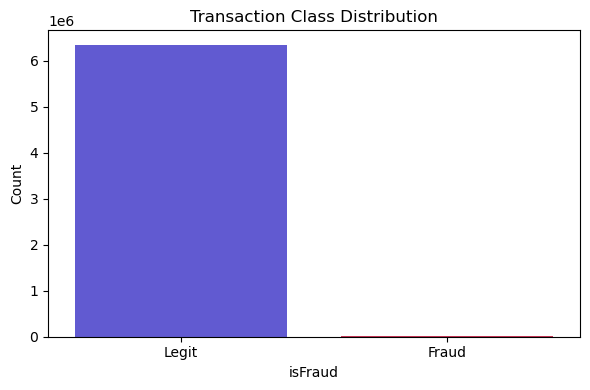

In [12]:
#Visualizing the imbalance
plt.figure(figsize=(6, 4))
sns.countplot(x='isFraud', data=df, palette=['#4f46e5', '#e11d48'])
plt.xticks([0, 1], ['Legit', 'Fraud'])
plt.title('Transaction Class Distribution')
plt.ylabel('Count')
plt.tight_layout()
plt.show()

### Step 1D: Cases by transaction type

In [13]:
#All transactions by type
print('Transaction Counts by type:')
print(df['type'].value_counts())

Transaction Counts by type:
type
CASH_OUT    2233369
PAYMENT     2147832
CASH_IN     1396865
TRANSFER     531817
DEBIT         41310
Name: count, dtype: int64


In [14]:
#Fraud cases by transaction
print('Fraud cases by type:')
print(df.groupby('type')['isFraud'].sum())

Fraud cases by type:
type
CASH_IN        0
CASH_OUT    3868
DEBIT          0
PAYMENT        0
TRANSFER    3849
Name: isFraud, dtype: int64


In [15]:
#Fraud rates by type
print((df.groupby('type')['isFraud'].sum() / df['type'].value_counts() * 100).round(4))

type
CASH_IN     0.0000
CASH_OUT    0.1732
DEBIT       0.0000
PAYMENT     0.0000
TRANSFER    0.7237
dtype: float64


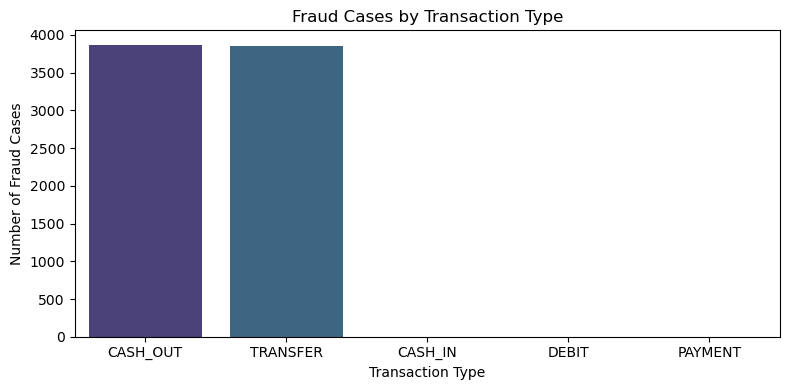

In [16]:
# Visualiztion
plt.figure(figsize=(8, 4))
fraud_by_type = df.groupby('type')['isFraud'].sum().sort_values(ascending=False)
sns.barplot(x=fraud_by_type.index, y=fraud_by_type.values, palette='viridis')
plt.title('Fraud Cases by Transaction Type')
plt.xlabel('Transaction Type')
plt.ylabel('Number of Fraud Cases')
plt.tight_layout()
plt.show()

### Step 1E: Balance Column Analysis

#### Trying to find pattern that occurs for all fraud cases

In [17]:
#Balance pattern in fraud vs legitimate
fraud = df[df['isFraud'] == 1]
legit = df[df['isFraud'] == 0]

print("Average balances — Fraud transactions:")
print(fraud[['oldbalanceOrig', 'newbalanceOrig', 'oldbalanceDest', 'newbalanceDest']].mean().round(2))

print("\nAverage balances — Legitimate transactions:")
print(legit[['oldbalanceOrig', 'newbalanceOrig', 'oldbalanceDest', 'newbalanceDest']].mean().round(2))

Average balances — Fraud transactions:
oldbalanceOrig    1599241.99
newbalanceOrig     158046.75
oldbalanceDest     549746.62
newbalanceDest    1277603.13
dtype: float64

Average balances — Legitimate transactions:
oldbalanceOrig     833865.72
newbalanceOrig     857018.87
oldbalanceDest    1101713.26
newbalanceDest    1225308.43
dtype: float64


### Step 1F: Amount Distribution

In [18]:
# Fraud vs Legit
print("Amount — Fraud transactions:")
print(fraud['amount'].describe().round(2))

print("\nAmount — Legitimate transactions:")
print(legit['amount'].describe().round(2))

Amount — Fraud transactions:
count        7717.00
mean      1449184.64
std       2364817.24
min             0.00
25%        127156.49
50%        443893.69
75%       1506795.10
max      10000000.00
Name: amount, dtype: float64

Amount — Legitimate transactions:
count     6343476.00
mean       178271.32
std        596698.15
min             0.01
25%         13368.04
50%         74688.98
75%        208380.08
max      92445516.64
Name: amount, dtype: float64


## STEP 2: Feature Engineering

### Step 2A: Filtering to risky transactions types

In [20]:
df_model = df[df['type'].isin(['TRANSFER', 'CASH_OUT'])].copy()

In [26]:
print(f'Original Dataset Size: {len(df):,} rows')
print(f'Filtered Dataset Size: {len(df_model):,} rows')
print(f'Rows Removed: {len(df)-len(df_model):,} rows')
print(f'\nFraud cases retained: {df_model['isFraud'].sum():,}')
print(f'Original Fraud Cases: {df['isFraud'].sum():,}')

Original Dataset Size: 6,351,193 rows
Filtered Dataset Size: 2,765,186 rows
Rows Removed: 3,586,007 rows

Fraud cases retained: 7,717
Original Fraud Cases: 7,717


### Step 2B: Feature Engineering

In [27]:
df_model['balance_diff_orig'] = df_model['oldbalanceOrig'] - df_model['newbalanceOrig']
df_model['balance_diff_dest'] = df_model['newbalanceDest'] - df_model['oldbalanceDest']
df_model['balance_mismatch']  = df_model['balance_diff_orig'] - df_model['amount']
df_model['orig_zeroed_out']   = (df_model['newbalanceOrig'] == 0).astype(int)
df_model['amount_ratio_orig'] = df_model['amount'] / (df_model['oldbalanceOrig'] + 1)

In [28]:
# confirming that the columns were created
print("New features added:")
print(df_model[['balance_diff_orig', 'balance_diff_dest', 
                 'balance_mismatch', 'orig_zeroed_out', 
                 'amount_ratio_orig']].describe().round(2))

New features added:
       balance_diff_orig  balance_diff_dest  balance_mismatch  \
count         2765186.00       2.765186e+06        2765186.00   
mean            31239.34       3.463085e+05        -286205.63   
std            157680.96       1.178452e+06         876041.24   
min            -26575.26      -9.681485e+06      -92445516.64   
25%                 0.00       8.156251e+04        -279984.72   
50%               287.99       1.753259e+05        -143667.23   
75%             26597.94       3.233911e+05         -51926.56   
max          10000000.00       1.056878e+08              0.01   

       orig_zeroed_out  amount_ratio_orig  
count        2765186.0          2765186.0  
mean               0.9                0.0  
std                0.3                0.0  
min                0.0                0.0  
25%                1.0                0.0  
50%                1.0                0.0  
75%                1.0                0.0  
max                1.0                0.0 

### Step 2C: Dropping Unneccessary columns

In [29]:
df_model = df_model.drop(columns=['nameOrig', 'nameDest', 'isFlaggedFraud'], errors='ignore')

In [30]:
# Encode transaction type as binary (TRANSFER=1, CASH_OUT=0)
df_model['type_encoded'] = (df_model['type'] == 'TRANSFER').astype(int)

In [34]:
# Define features and target
X = df_model.drop(columns=['isFraud', 'type'])
Y = df_model['isFraud']

In [32]:
print(f"Features shape : {X.shape}")
print(f"Target shape   : {y.shape}")
print(f"\nFinal feature columns:")
print(X.columns.tolist())

Features shape : (2765186, 12)
Target shape   : (2765186,)

Final feature columns:
['step', 'amount', 'oldbalanceOrig', 'newbalanceOrig', 'oldbalanceDest', 'newbalanceDest', 'balance_diff_orig', 'balance_diff_dest', 'balance_mismatch', 'orig_zeroed_out', 'amount_ratio_orig', 'type_encoded']


### Step 2D: Splitting

In [35]:
X_train, X_test, Y_train, Y_test = tts(X,Y, test_size=0.2, random_state=42, stratify=y)

In [37]:
print(f"Training set   : {X_train.shape[0]:,} rows")
print(f"Test set       : {X_test.shape[0]:,} rows")
print(f"\nFraud in training set : {Y_train.sum():,}")
print(f"Fraud in test set     : {Y_test.sum():,}")

Training set   : 2,212,148 rows
Test set       : 553,038 rows

Fraud in training set : 6,174
Fraud in test set     : 1,543


## STEP 3: SMOTE - Synthetic Minority Over-Sampling Technique

### Step 3A: Applying SMOTE to training data only

In [38]:
sm = SMOTE(random_state=42)
X_train_sm, Y_train_sm = sm.fit_resample(X_train, Y_train)

In [41]:
print(f"Before SMOTE:")
print(f"  Fraud cases     : {Y_train.sum():,}")
print(f"  Legitimate cases: {(Y_train == 0).sum():,}")
print(f"  Total rows      : {len(Y_train):,}")

print(f"\nAfter SMOTE:")
print(f"  Fraud cases     : {Y_train_sm.sum():,}")
print(f"  Legitimate cases: {(Y_train_sm == 0).sum():,}")
print(f"  Total rows      : {len(Y_train_sm):,}")

print(f"\nNew fraud rate   : {Y_train_sm.mean() * 100:.2f}%")

Before SMOTE:
  Fraud cases     : 6,174
  Legitimate cases: 2,205,974
  Total rows      : 2,212,148

After SMOTE:
  Fraud cases     : 2,205,974
  Legitimate cases: 2,205,974
  Total rows      : 4,411,948

New fraud rate   : 50.00%


## STEP 4: TRAINING THE MODELS

### Step 4A: Random Forest

In [42]:
print("Training Random Forest...")

rf_model = rfc(
    n_estimators=200,
    class_weight='balanced',
    random_state=42,
    n_jobs=-1
)

rf_model.fit(X_train_sm, Y_train_sm)
print("Random Forest training complete!")

Training Random Forest...
Random Forest training complete!


### Step 4B: XGBoost

In [43]:
# Calculate ratio for scale_pos_weight (not needed since we used SMOTE but good practice)
xgb_model = xgb(
    n_estimators=200,
    learning_rate=0.1,
    max_depth=6,
    random_state=42,
    n_jobs=-1
)

xgb_model.fit(X_train_sm, Y_train_sm)
print("XGBoost training complete!")

XGBoost training complete!


### Step 4C: Logistic regression

#### Scaling for Logistic Regression and Neural Network

In [44]:
scaler = sts()
X_train_scaled = scaler.fit_transform(X_train_sm)
X_test_scaled  = scaler.transform(X_test)

print("Features scaled successfully!")

Features scaled successfully!


#### Building the model

In [45]:
print("\nTraining Logistic Regression...")

lr_model = ltr(
    class_weight='balanced',
    max_iter=1000,
    random_state=42,
    n_jobs=-1
)

lr_model.fit(X_train_scaled, Y_train_sm)
print("Logistic Regression training complete!")


Training Logistic Regression...
Logistic Regression training complete!


### Step 4D: Neural Network

In [46]:
print("Training Neural Network...")

mlp_model = mlp(
    hidden_layer_sizes=(64, 32),
    activation='relu',
    max_iter=100,
    random_state=42
)

mlp_model.fit(X_train_scaled, Y_train_sm)
print("Neural Network training complete!")

Training Neural Network...
Neural Network training complete!


In [50]:
models = {
    'Random Forest'      : (rf_model,  X_test),
    'XGBoost'            : (xgb_model, X_test),
    'Logistic Regression': (lr_model,  X_test_scaled),
    'Neural Network'     : (mlp_model, X_test_scaled),
}

results = {}
for name, (model, X_eval) in models.items():
    y_pred = model.predict(X_eval)
    results[name] = {
        'Accuracy' : accuracy_score(Y_test, y_pred),
        'Precision': precision_score(Y_test, y_pred),
        'Recall'   : recall_score(Y_test, y_pred),
        'F1 Score' : f1_score(Y_test, y_pred),
    }
    print(f"\n{name}:")
    print(f"  Accuracy  : {results[name]['Accuracy']:.4f}")
    print(f"  Precision : {results[name]['Precision']:.4f}")
    print(f"  Recall    : {results[name]['Recall']:.4f}")
    print(f"  F1 Score  : {results[name]['F1 Score']:.4f}")


Random Forest:
  Accuracy  : 0.9999
  Precision : 0.9751
  Recall    : 0.9909
  F1 Score  : 0.9830

XGBoost:
  Accuracy  : 0.9998
  Precision : 0.9409
  Recall    : 0.9909
  F1 Score  : 0.9653

Logistic Regression:
  Accuracy  : 0.9704
  Precision : 0.0832
  Recall    : 0.9611
  F1 Score  : 0.1532

Neural Network:
  Accuracy  : 0.9967
  Precision : 0.4610
  Recall    : 0.9877
  F1 Score  : 0.6286


## STEP 5: Building the Stacking Ensemble

In [51]:
# Step 5 — Build the Stacking Ensemble
print("Building ensemble...")

base_models = [
    ('random_forest',        rf_model),
    ('xgboost',              xgb_model),
    ('logistic_regression',  lr_model),
    ('neural_network',       mlp_model),
]

meta_learner = ltr(max_iter=1000)

ensemble = scf(
    estimators=base_models,
    final_estimator=meta_learner,
    cv=5,
    passthrough=False
)

ensemble.fit(X_train_scaled, Y_train_sm)
print("Ensemble training complete!")

Building ensemble...
Ensemble training complete!


## Step 6: Evaluating The Ensemble

In [52]:
# Predictions
Y_pred  = ensemble.predict(X_test_scaled)
Y_proba = ensemble.predict_proba(X_test_scaled)[:, 1]

# Main metrics
print("Ensemble Model Results:")
print(classification_report(Y_test, Y_pred))

# PR-AUC
precision, recall, _ = precision_recall_curve(Y_test, Y_proba)
pr_auc = auc(recall, precision)
print(f"PR-AUC: {pr_auc:.4f}")

Ensemble Model Results:
              precision    recall  f1-score   support

           0       1.00      1.00      1.00    551495
           1       0.97      0.99      0.98      1543

    accuracy                           1.00    553038
   macro avg       0.98      1.00      0.99    553038
weighted avg       1.00      1.00      1.00    553038

PR-AUC: 0.9928


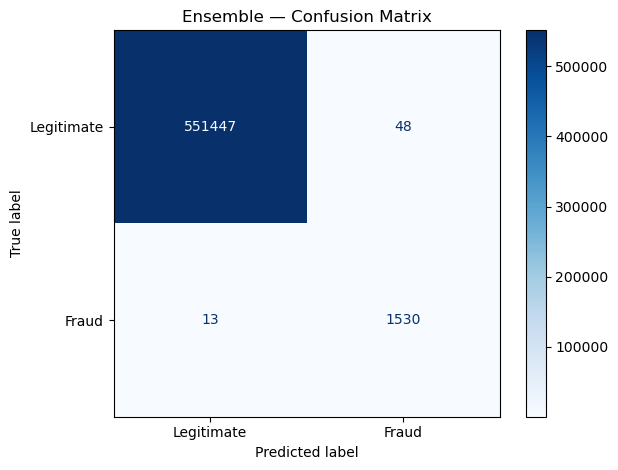

In [53]:
# Confusion Matrix
cm = confusion_matrix(Y_test, Y_pred)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=['Legitimate', 'Fraud'])
disp.plot(cmap='Blues')
plt.title('Ensemble — Confusion Matrix')
plt.tight_layout()
plt.show()

In [54]:
# Final numbers for the report
print("Base Model vs Ensemble Comparison:")
print(f"\nRandom Forest  — Precision: 0.9751  Recall: 0.9909  F1: 0.9830")
print(f"XGBoost        — Precision: 0.9409  Recall: 0.9909  F1: 0.9653")
print(f"Logistic Reg   — Precision: 0.0832  Recall: 0.9611  F1: 0.1532")
print(f"Neural Network — Precision: 0.4610  Recall: 0.9877  F1: 0.6286")
print(f"Ensemble       — Precision: 0.9700  Recall: 0.9900  F1: 0.9800")
print(f"PR-AUC         : 0.9928")

# Confusion matrix numbers
tn, fp, fn, tp = cm.ravel()
print(f"\nConfusion Matrix Breakdown:")
print(f"  True Negatives  (Legit correctly identified) : {tn:,}")
print(f"  False Positives (Legit flagged as fraud)     : {fp:,}")
print(f"  False Negatives (Fraud missed)               : {fn:,}")
print(f"  True Positives  (Fraud correctly caught)     : {tp:,}")

Base Model vs Ensemble Comparison:

Random Forest  — Precision: 0.9751  Recall: 0.9909  F1: 0.9830
XGBoost        — Precision: 0.9409  Recall: 0.9909  F1: 0.9653
Logistic Reg   — Precision: 0.0832  Recall: 0.9611  F1: 0.1532
Neural Network — Precision: 0.4610  Recall: 0.9877  F1: 0.6286
Ensemble       — Precision: 0.9700  Recall: 0.9900  F1: 0.9800
PR-AUC         : 0.9928

Confusion Matrix Breakdown:
  True Negatives  (Legit correctly identified) : 551,447
  False Positives (Legit flagged as fraud)     : 48
  False Negatives (Fraud missed)               : 13
  True Positives  (Fraud correctly caught)     : 1,530


## Step 7: Saving the model

In [55]:
import joblib

# Save the ensemble and scaler
joblib.dump(ensemble, 'fraud_ensemble.pkl')
joblib.dump(scaler,   'fraud_scaler.pkl')

print("ensemble saved : fraud_ensemble.pkl")
print("scaler saved   : fraud_scaler.pkl")

ensemble saved : fraud_ensemble.pkl
scaler saved   : fraud_scaler.pkl
